In [2]:
import numpy as np
import pandas as pd
import pingouin as pg

import statsmodels.api as sm
from statsmodels.formula.api import ols

import seaborn as sns
from matplotlib import pyplot as plt

# fig3a

/tmp/ipykernel_88972/2162664146.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=x_var, y=var, order=order,
/tmp/ipykernel_88972/2162664146.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x=x_var, y=var, order=order,
/tmp/ipykernel_88972/2162664146.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(title='{}'.format(po), ylabel=ylabel,
/tmp/ipykernel_88972/2162664146.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=x_var, y=var, or


=== Ext. Data Fig. 4a — peak field rate (ShockObs+ vs. unresponsive) ===
  dorsal — peak field rate
               T       dof alternative     p_val            CI95   cohen_d     power   BF10
T_test  2.236808  4.662497   two-sided  0.079394  [-1.25, 15.55]  1.052206  0.605638  2.291

  intermediate — peak field rate
               T        dof alternative     p_val          CI95   cohen_d     power   BF10
T_test  2.366576  26.991466   two-sided  0.025386  [0.54, 7.53]  0.664511  0.822281  2.623

  ventral — peak field rate
               T       dof alternative     p_val            CI95   cohen_d     power   BF10
T_test  0.475925  5.120115   two-sided  0.653744  [-8.96, 13.06]  0.399716  0.156334  0.412


=== Ext. Data Fig. 4a — spatial information (ShockObs+ vs. unresponsive) ===
  dorsal — spatial information
               T       dof alternative    p_val          CI95   cohen_d     power   BF10
T_test  1.856943  4.175663   two-sided  0.13387  [-0.46, 2.4]  1.472945  0.878738  1.33

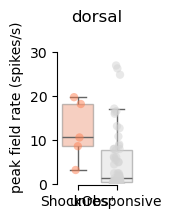

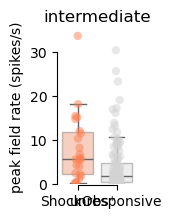

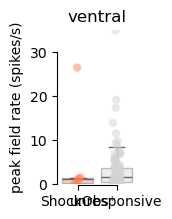

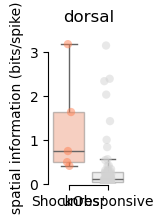

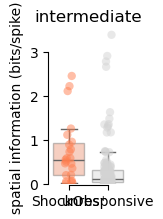

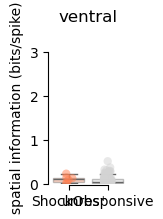

In [6]:
tmp = pd.read_parquet('SuppFig4a.parquet')

var_list  = ['field_peak_rate', 'spatial_info']
labels    = ['peak field rate (spikes/s)', 'spatial information (bits/spike)']
ylims     = [(0, 35), (0, 3.5)]
x_var     = 'response'
order     = ['ShockObs+', 'rest']
xtick_lab = ['ShockObs⁺', 'unresponsive']

for var, ylabel, ylim in zip(var_list, labels, ylims):
    for po in ['dorsal', 'intermediate', 'ventral']:
        fig, ax = plt.subplots(1, 1, figsize=(1.0, 2.0))
        sns.boxplot(x=x_var, y=var, order=order,
                    palette=['coral', 'lightgrey'],
                    boxprops=dict(alpha=0.4), fliersize=0.0, ax=ax,
                    data=tmp.query("phase == 'context' and pole == '{}' and condition == 'shock'".format(po)))
        sns.stripplot(x=x_var, y=var, order=order,
                      palette=['coral', 'lightgrey'],
                      size=6, alpha=0.5, dodge=False, ax=ax,
                      data=tmp.query("phase == 'context' and pole == '{}' and condition == 'shock'".format(po)))
        ax.set(title='{}'.format(po), ylabel=ylabel,
               xlabel='', xticklabels=xtick_lab, ylim=ylim)
        plt.xticks(rotation=25, ha='right')
        sns.despine(offset=True, trim=True)

stats = []

for var, label in [('field_peak_rate', 'peak field rate'),
                    ('spatial_info',    'spatial information')]:
    stats.append("")
    stats.append("=== Ext. Data Fig. 4a — {} (ShockObs+ vs. unresponsive) ===".format(label))
    for pole in ['dorsal', 'intermediate', 'ventral']:
        results = pg.ttest(
            tmp.query("phase == 'context' and condition == 'shock' and response == 'ShockObs+' and pole == '{}'".format(pole))[var],
            tmp.query("phase == 'context' and condition == 'shock' and response == 'rest'    and pole == '{}'".format(pole))[var],
            paired=False)
        stats.append("  {} — {}".format(pole, label))
        stats.append(results.to_string())
        stats.append("")

for line in stats:
    print(line)


# fig4b

/tmp/ipykernel_88972/3404953854.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[p].set(title='{} hippocampus'.format(po),
/tmp/ipykernel_88972/3404953854.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[p].set(title='{} hippocampus'.format(po),
/tmp/ipykernel_88972/3404953854.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[p].set(title='{} hippocampus'.format(po),
/tmp/ipykernel_88972/3404953854.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[p].set(title='{} hippocampus'.format(po),
/tmp/ipykernel_88972/3404953854.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or


━━━ dorsal hippocampus ━━━
  peak field rate — two-way ANOVA: context × phase
              Source            SS     DF         MS         F     p_unc       np2
0          condition     37.961624    1.0  37.961624  0.741199  0.390076  0.002865
1              phase      8.704152    1.0   8.704152  0.169948  0.680500  0.000658
2  condition * phase      1.265291    1.0   1.265291  0.024705  0.875228  0.000096
3           Residual  13213.857199  258.0  51.216501       NaN       NaN       NaN

            Contrast condition        A      B Paired Parametric         T         dof alternative     p_unc  p_corr p_adjust   BF10     cohen
0          condition         -     ctrl  shock  False       True -0.861171  259.489742   two-sided  0.389939     NaN      NaN  0.193 -0.106361
1              phase         -  context   test  False       True -0.406601  259.933208   two-sided  0.684636     NaN      NaN  0.147 -0.050242
2  condition * phase      ctrl  context   test  False       True -0.414013  

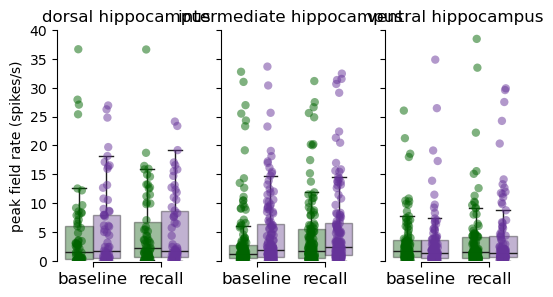

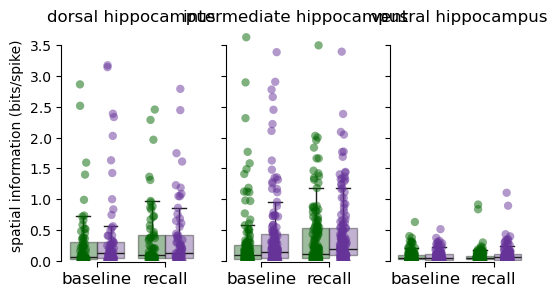

In [8]:
plt.rc('xtick', labelsize=12)

tmp = pd.read_parquet('SuppFig4b.parquet')

order = ['context', 'test']

for var, ylabel, ylim in [('field_peak_rate', 'peak field rate (spikes/s)', (0, 40)),
                           ('spatial_info',    'spatial information (bits/spike)', (0, 3.75))]:

    fig, ax = plt.subplots(1, 3, figsize=(6, 3), sharex=True, sharey=True)

    for p, po in enumerate(['dorsal', 'intermediate', 'ventral']):
        data_po = tmp.query("(phase == 'context' or phase == 'test') and pole == '{}'".format(po))
        sns.boxplot(x='phase', y=var, hue='condition',
                    order=order, hue_order=['ctrl', 'shock'],
                    palette=['darkgreen', 'rebeccapurple'],
                    boxprops=dict(alpha=0.4), fliersize=0.0, ax=ax[p],
                    data=data_po)
        sns.stripplot(x='phase', y=var, hue='condition',
                      order=order, hue_order=['ctrl', 'shock'],
                      palette=['darkgreen', 'rebeccapurple'],
                      size=6, alpha=0.5, dodge=True, ax=ax[p],
                      data=data_po)
        ax[p].set(title='{} hippocampus'.format(po),
                  xlabel='', ylabel='',
                  xticklabels=['baseline', 'recall'],
                  ylim=ylim)
        ax[p].get_legend().remove()

    ax[0].set(ylabel=ylabel)
    sns.despine(offset=True, trim=True)


stats = []

for pole in ['dorsal', 'intermediate', 'ventral']:
    stats.append("")
    stats.append("━━━ {} hippocampus ━━━".format(pole))

    for var, label in [('field_peak_rate', 'peak field rate'),
                        ('spatial_info',    'spatial information')]:
        data = tmp.query("(phase == 'context' or phase == 'test') and pole == '{}'".format(pole))[
            [var, 'condition', 'phase']]

        results  = pg.anova(data=data, dv=var, between=['condition', 'phase'], ss_type=2)
        posthoc1 = pg.pairwise_tests(dv=var, between=['condition', 'phase'],
                                      padjust='holm', effsize='cohen', data=data)
        stats.append("  {} — two-way ANOVA: context × phase".format(label))
        stats.append(results.to_string())
        stats.append("")
        stats.append(posthoc1.to_string())
        stats.append("")

for line in stats:
    print(line)